In [1]:
!pip install -r requirements.txt --quiet


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [1]:
%matplotlib inline
import pymc as pm
import numpy as np
import pandas as pd
from scipy.stats import norm, binom, bernoulli, lognorm, betabinom
from scipy.stats import beta as beta_dist
from scipy.special import expit as inv_logit
from scipy.special import logit ,logsumexp
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import arviz as az
import networkx as nx
import xarray as xr

import collections.abc
collections.Iterable = collections.abc.Iterable
from causalgraphicalmodels import CausalGraphicalModel
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
from matplotlib.patches import FancyArrowPatch

import warnings
warnings.filterwarnings('ignore')


%config InlineBackend.figure_format = 'retina'

plt.style.use(['seaborn-v0_8-darkgrid','seaborn-v0_8-colorblind'])

#### Code 12.1

<Axes: ylabel='Density'>

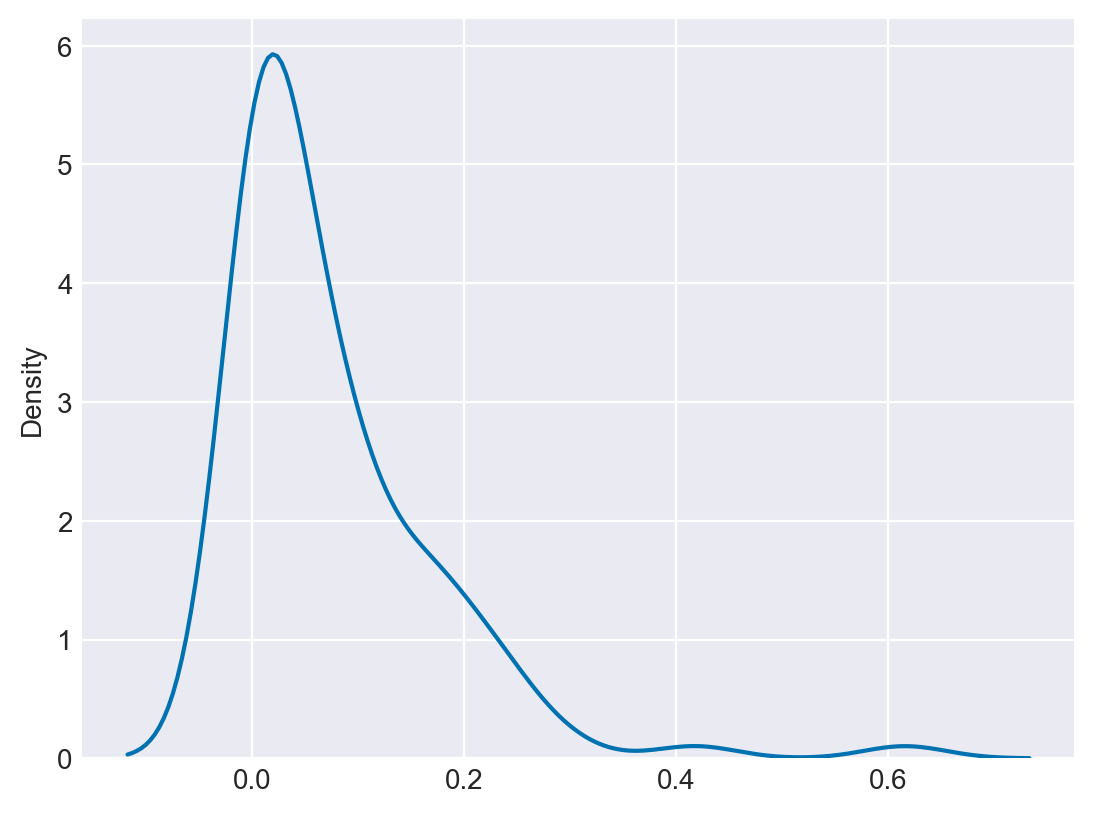

In [3]:
pbar = .5
theta = 5
sns.kdeplot(np.random.beta(pbar, theta,100))

#### Code  12.2

In [6]:
d = pd.read_csv('data/UCBadmit.csv', sep = ';')
d['gid'] = np.where(d['applicant.gender'] == 'male', 0, 1)
dat = pd.DataFrame({
    'A': d.admit, 
    'N' : d.applications,
    'gid' : d.gid,
})

with pm.Model() as m12_1:
    phi = pm.Exponential('phi',1)
    theta = pm.Deterministic('theta', phi + 2.0)
    a = pm.Normal('a', 0, 1.5, shape = len(dat.gid.unique()))
    pbar = pm.Deterministic('pbar', pm.math.invlogit(a[dat.gid]))

    # beta-binomial parameters in pymc use different parameterization so this extra step is needed
    alpha= pm.Deterministic('alpha', pbar * theta) 
    beta = pm.Deterministic('beta', (1 - pbar) * theta)

    A = pm.BetaBinomial('A', n = dat.N, alpha = alpha, beta = beta, observed = dat.A)
    trace_12_1 = pm.sample(cores = 1, idata_kwargs = {'log_likelihood': True})


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [phi, a]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 2 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics


#### Code 12.3

In [7]:
trace_12_1.posterior['da'] = trace_12_1.posterior['a'].sel(a_dim_0 = 0) - trace_12_1.posterior['a'].sel(a_dim_0 = 1)
pm.summary(trace_12_1, var_names = ['a','phi','theta','da'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[0],-0.447,0.404,-1.156,0.370,0.013,0.009,976.0,957.0,1.0
a[1],-0.328,0.395,-1.128,0.399,0.011,0.009,1207.0,1136.0,1.0
phi,1.042,0.792,0.000,2.483,0.020,0.014,1039.0,439.0,1.0
theta,3.042,0.792,2.000,4.483,0.020,0.014,1039.0,439.0,1.0
da,-0.119,0.555,-1.215,0.892,0.016,0.013,1158.0,1067.0,1.0


#### Code 12.4

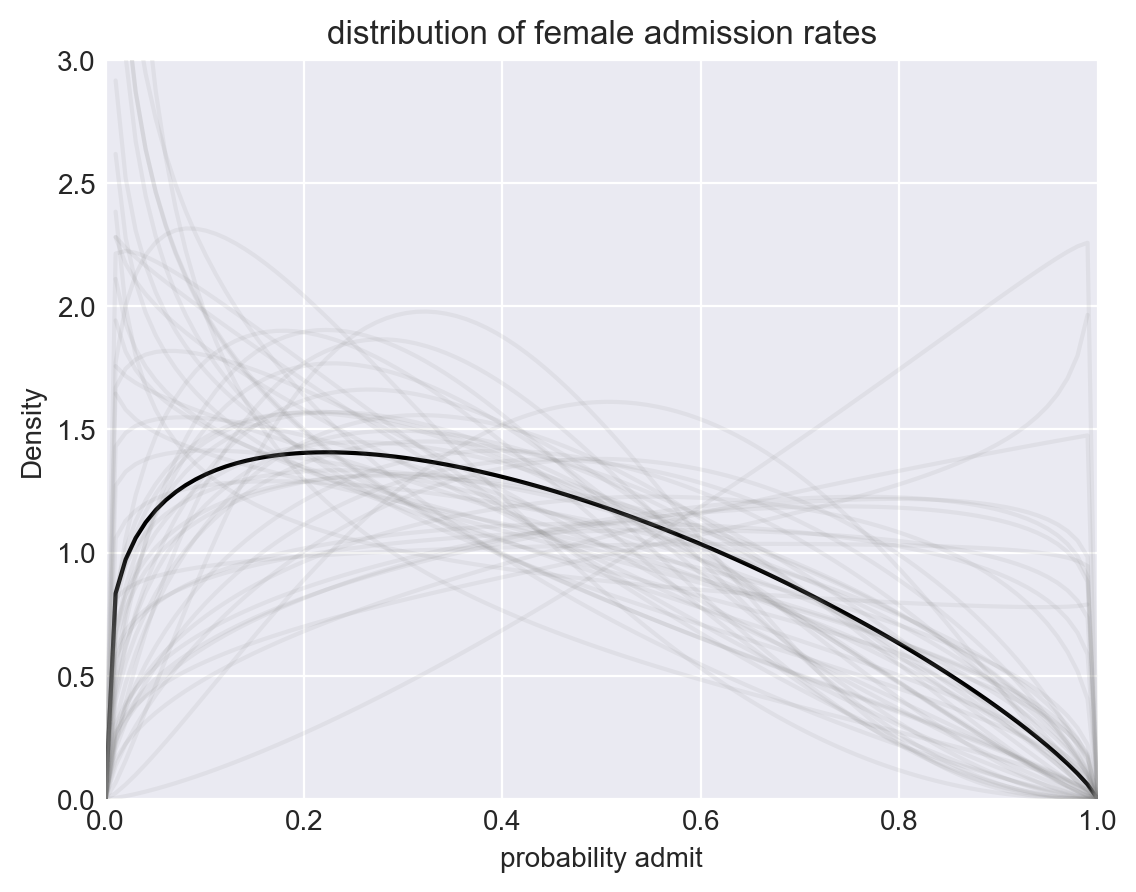

In [8]:
gid = 1
x = np.linspace(0,1,100)
# draw posterior mean beta distribution
alpha_mean = trace_12_1.posterior.alpha.values.mean()
beta_mean = trace_12_1.posterior.beta.values.mean()
plt.plot(x, beta_dist.pdf(x, alpha_mean, beta_mean), color = 'black');

samp_50 = trace_12_1.posterior.sel(a_dim_0 = gid).to_dataframe().reset_index().sample(50)

for i, row in samp_50.iterrows():
    plt.plot(x, beta_dist.pdf(x, row.alpha, row.beta), color = 'grey', alpha = 0.1)
plt.xlim(0,1);
plt.ylim(0,3);
plt.xlabel('probability admit');
plt.ylabel('Density');
plt.title('distribution of female admission rates');
    

#### Code 12.5

In [10]:
d.head()

,dept,applicant.gender,admit,reject,applications,gid
1,A,male,512,313,825,0
2,A,female,89,19,108,1
3,B,male,353,207,560,0
4,B,female,17,8,25,1
5,C,male,120,205,325,0


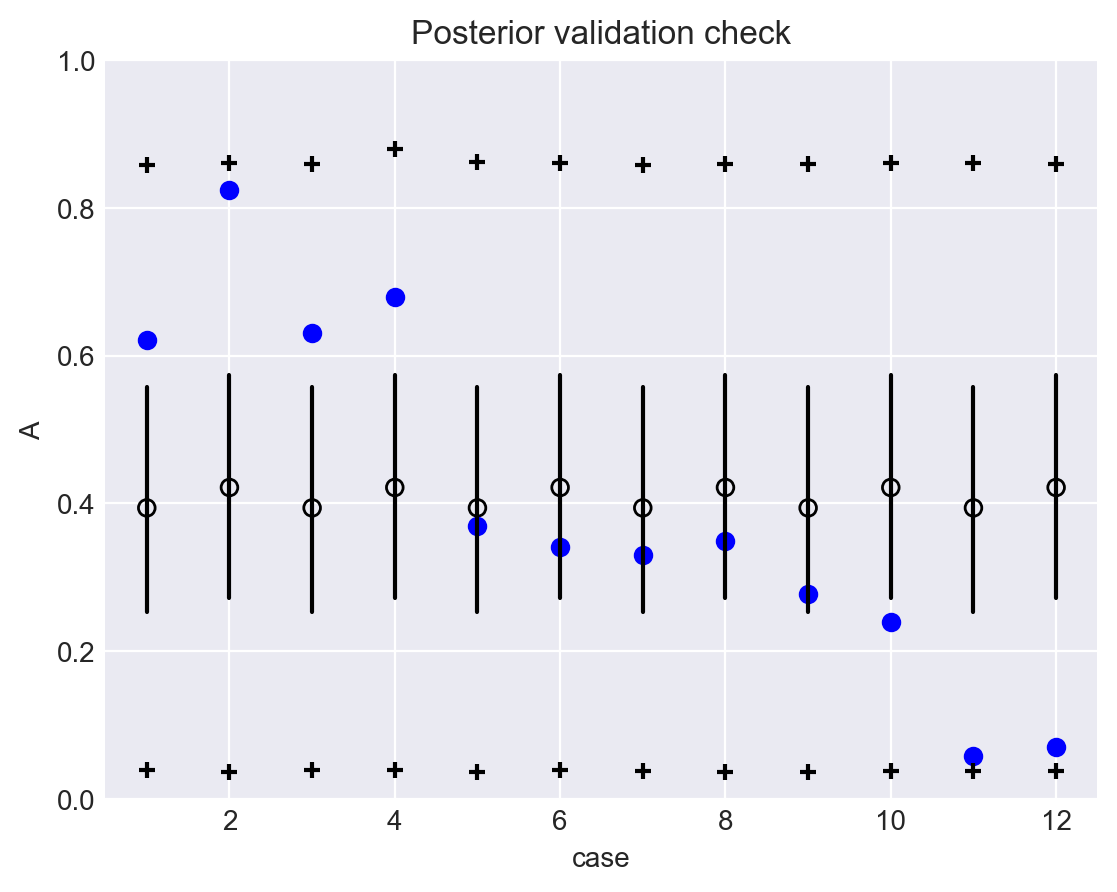

In [11]:
post = trace_12_1.posterior.to_dataframe().reset_index() 
post['case'] = post.pbar_dim_0 + 1
d_grouped = d.groupby(['dept','gid'])[['admit','reject']].sum().reset_index()
d_grouped['case'] = d.index
d_grouped['rate'] = d_grouped['admit'] / (d_grouped['admit'] + d_grouped['reject'])

for i in post.case.unique():
    postcheck = post.loc[post.case == i]
    mean = postcheck.pbar.mean()
    hdi = postcheck.pbar.quantile([0.055, 0.945])
    pred_count = betabinom.rvs(d.applications.loc[d.index == i].values[0], postcheck.alpha, postcheck.beta) / d.applications.loc[d.index == i].values[0]
    pred_count_hdi = np.quantile(pred_count, [0.055, 0.945])
    plt.scatter(i, mean, marker = 'o', facecolor = 'none', edgecolor = 'black')
    plt.scatter(i, d_grouped['rate'].loc[d_grouped['case'] == i].values[0], marker = 'o', color = 'blue')
    plt.scatter(i, pred_count_hdi[0], color = 'black', marker = '+');
    plt.scatter(i, pred_count_hdi[1], color = 'black', marker = '+');
    plt.plot([i,i], hdi, color = 'black');
plt.xlabel('case');
plt.ylabel('A');
plt.title('Posterior validation check');
plt.ylim(0,1);
plt.xlim(.5,12.5);


#### Code 12.6

In [12]:
d = pd.read_csv('data/Kline.csv', sep = ';')
d['P'] = scale.fit_transform(np.log(d[['population']]))
d['contact_id'] = np.where(d['contact'] == 'high', 1, 0)

dat2 = pd.DataFrame({
    'T': d.total_tools,
    'P': d.population,
    'cid': d.contact_id
})

with pm.Model() as m12_2:
    phi = pm.Exponential('phi', 1)
    g = pm.Exponential('g', 1)
    a = pm.Normal('a', 1,1, shape = len(dat2.cid.unique()))
    b = pm.Exponential('b', 1, shape = len(dat2.cid.unique()))
    lambdas = pm.Deterministic(
        'lambdas', 
        pm.math.exp(a[dat2.cid.values]) * dat2.P.values ** b[dat2.cid.values] / g
    )    
    T = pm.NegativeBinomial('T', mu=lambdas, alpha=phi, observed=dat2.T.values)
    trace_m12_2 = pm.sample(cores = 1, idata_kwargs={'log_likelihood': True})
    


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [phi, g, a, b]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 6 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics


#### Code 12.7

In [13]:
prob_drink = .2
rate_work = 1

N = 365
drink = np.random.binomial(1, prob_drink, N)

y = (1-drink) * np.random.poisson(rate_work, N)


#### Code 12.8

Text(0, 0.5, 'Frequency')

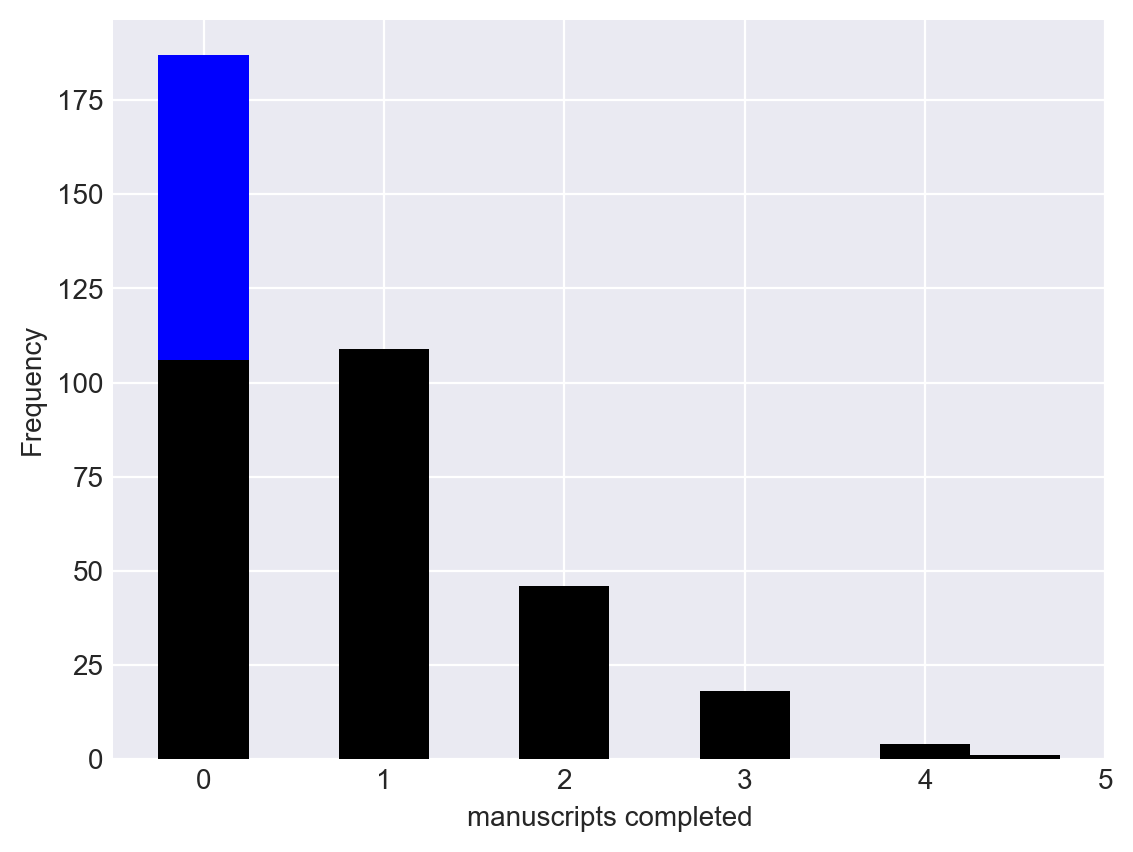

In [14]:
plt.hist(y, width=0.5, color='black', align= 'left' )

zeros_drink = np.sum(drink == 1)  
zeros_work = np.sum((y == 0) & (drink == 0))  


plt.bar(0, zeros_drink, bottom=zeros_work, width=0.5, color='blue', align = 'center')

plt.xlabel('manuscripts completed')
plt.ylabel('Frequency')


#### Code 12.9

In [15]:
with pm.Model() as m12_3: 
    al = pm.Normal('al', 1, .5)
    ap = pm.Normal('ap', -1.5, 1)
    log_lambda = pm.math.exp(al)
    logit_p = pm.math.sigmoid(ap)
    y_obs = pm.ZeroInflatedPoisson('y_obs', mu = log_lambda, psi = logit_p, observed = y)
    trace_12_3 = pm.sample(cores = 1, idata_kwargs = {'log_likelihood': True})
pm.summary(trace_12_3)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [al, ap]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
al,0.016,0.085,-0.151,0.166,0.003,0.002,776.0,617.0,1.0
ap,1.108,0.297,0.616,1.687,0.011,0.009,754.0,639.0,1.0


#### Code 12.10

In [16]:
print(inv_logit(trace_12_3.posterior.ap.values).mean())
print(np.exp(trace_12_3.posterior.al.values).mean())

0.7476422383396898
1.0192977657071116


#### Code 12.11

_This is some under the hood STAN stuff and is not relevant to how PyMC computes ZIPoisson_

#### Code 12.12

In [17]:
d = pd.read_csv('data/Trolley.csv', sep = ';') 
d['id'] = d['id'].str.replace(';','-')


#### Code 12.13

Text(0.5, 0, 'response')

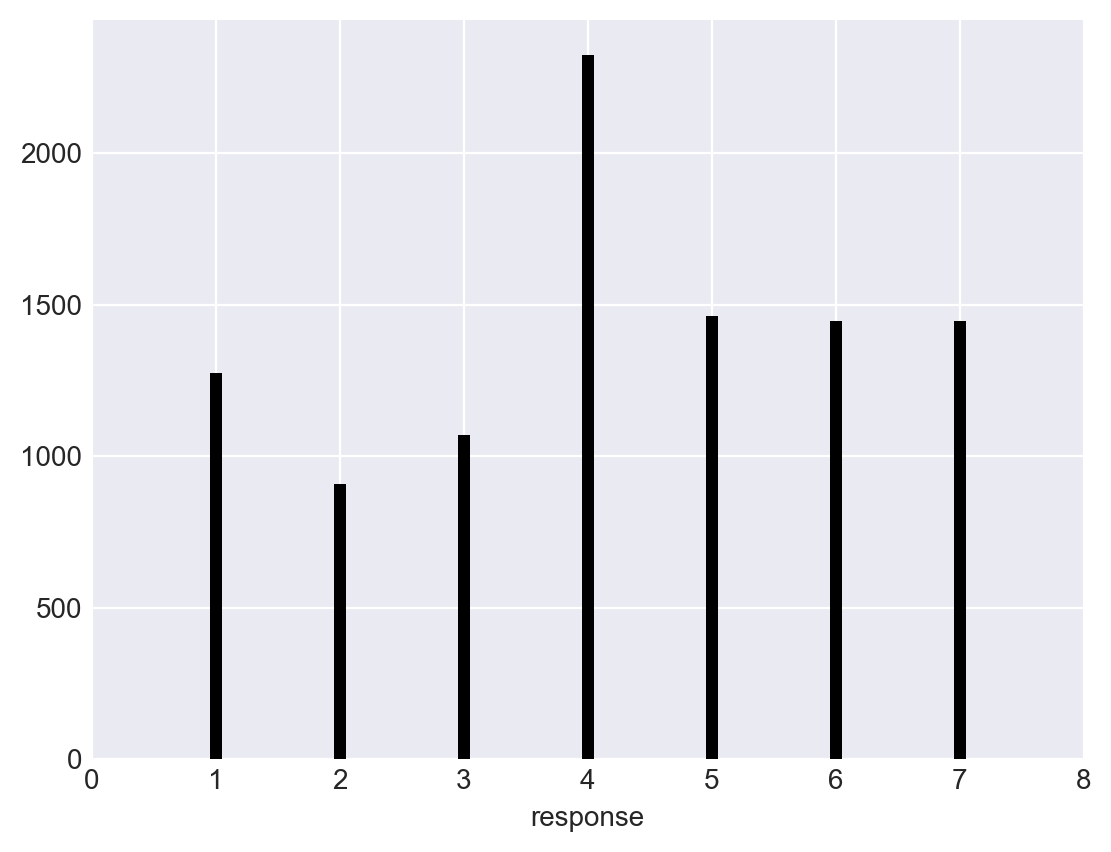

In [18]:
plt.hist(d.response, bins = np.arange(.5,8.5,1), rwidth = .1, color= 'black')
plt.xlim(0,8)
plt.xlabel('response')

#### Code 12.14

(0.0, 1.05)

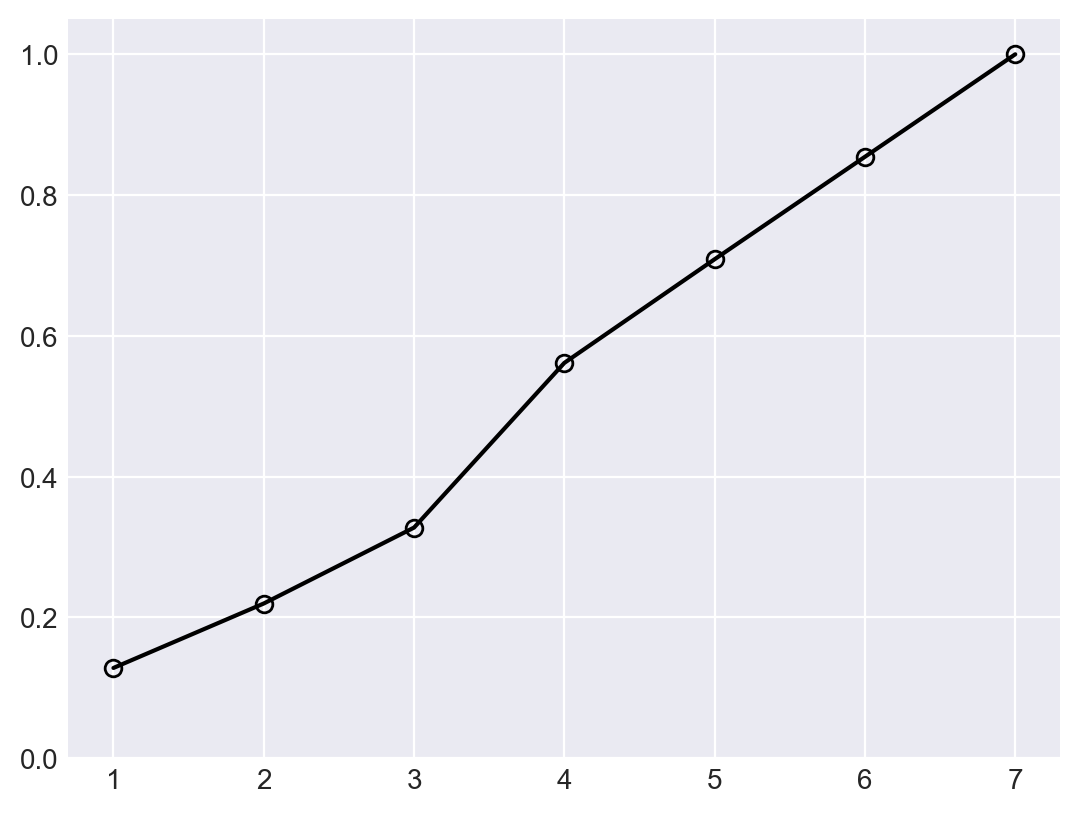

In [19]:
pr_k = d['response'].value_counts(normalize=True).sort_index()
cum_pr_k = pr_k.cumsum()

plt.plot(np.arange(1,8),cum_pr_k, 'o-r', color = 'black', fillstyle ='none')
plt.ylim(0,1.05)


#### Code 12.15

In [20]:
logit_pr_r = pd.DataFrame({'response': np.arange(7), 'logit_val': logit(cum_pr_k)}).reset_index(drop=True)

logit_d = logit_pr_r[~logit_pr_r['logit_val'].isna()]

#plt.plot(np.arange(1,8),logit_pr_r, 'o-r', color = 'black', fillstyle ='none')

logit_d

,response,logit_val
0,0,-1.916091
1,1,-1.266606
2,2,-0.718634
3,3,0.247786
4,4,0.889864
5,5,1.769381


#### Code 12.16-12.17

_Note: 12.17 is just the same model written in quap instead of Ulam._

In [21]:
logit_d['response'].values

array([0, 1, 2, 3, 4, 5])

In [22]:
d.head()

,case,response,order,id,age,male,edu,action,intention,contact,story,action2
0,cfaqu,4,2,96-434,14,0,Middle School,0,0,1,aqu,1
1,cfbur,3,31,96-434,14,0,Middle School,0,0,1,bur,1
2,cfrub,4,16,96-434,14,0,Middle School,0,0,1,rub,1
3,cibox,3,32,96-434,14,0,Middle School,0,1,1,box,1
4,cibur,3,4,96-434,14,0,Middle School,0,1,1,bur,1


In [23]:
with pm.Model() as m12_4:
    cutpoints = pm.Normal('cutpoints', 0, 1.5, shape=6,
                          initval=np.array([-1.5, -1.0, -0.5, 0, 0.5, 1.0]))
    R = pm.OrderedLogistic('R', eta=0, cutpoints=cutpoints, 
                           observed=d['response'].values - 1)
    trace_m12_4 = pm.sample(cores = 1,init="adapt_diag")

Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [cutpoints]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 12 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


#### Code 12.18

In [24]:
summary = pm.summary(trace_m12_4, var_names = ['cutpoints'])

#### Code 12.19

In [25]:
round(inv_logit(summary['mean']),3)


cutpoints[0]    0.128
cutpoints[1]    0.220
cutpoints[2]    0.328
cutpoints[3]    0.562
cutpoints[4]    0.709
cutpoints[5]    0.855
Name: mean, dtype: float64

#### Code 12.20

In [26]:
trace_m12_4.posterior.cutpoints.values.reshape(-1,6).mean(axis=0)

array([-1.9162171 , -1.2664806 , -0.71883824,  0.24810721,  0.89011775,
        1.77050712])

In [27]:
cutpoints = inv_logit(trace_m12_4.posterior.cutpoints.values.reshape(-1,6).mean(axis=0))

pk = np.concatenate([[cutpoints[0]], 
                     np.diff(cutpoints), 
                     [1 - cutpoints[-1]]])
print(np.round(pk, 2))

[0.13 0.09 0.11 0.23 0.15 0.15 0.15]


#### Code 12.21

In [28]:
np.sum(pk * np.arange(1,8))

4.199061061771911

#### Code 12.22

In [29]:
cutpoints = inv_logit(trace_m12_4.posterior.cutpoints.values.reshape(-1,6).mean(axis=0) -.5)

print(cutpoints )

pk = np.concatenate([[cutpoints[0]], 
                     np.diff(cutpoints), 
                     [1 - cutpoints[-1]]])
print(np.round(pk, 2))

[0.08194439 0.14598055 0.22814096 0.43735767 0.59631104 0.78082955]
[0.08 0.06 0.08 0.21 0.16 0.18 0.22]


#### Code 12.23

In [30]:
np.sum(pk * np.arange(1,8))

4.729435833007758

#### Code 12.24

In [31]:
dat = pd.DataFrame({
    'R': d.response.values - 1,
    'A': d.action,
    'I': d.intention,
    'C': d.contact
})

with pm.Model() as model:
    cutpoints = pm.Normal('cutpoints', 0, 1.5, shape=6,
                          initval=np.array([-1.5, -1.0, -0.5, 0, 0.5, 1.0]))
    bA = pm.Normal('bA', 0, .5)
    bI = pm.Normal('bI', 0, .5) 
    bC = pm.Normal('bC', 0, .5)
    bIA = pm.Normal('bIA', 0, .5)
    bIC = pm.Normal('bIC', 0, .5)
    BI = pm.Deterministic('BI', bI + bIA * dat.A + bIC * dat.C)
    phi  = pm.Deterministic('phi', bA * dat.A + bC * dat.C + BI * dat.I)
    R = pm.OrderedLogistic('R', eta=phi, cutpoints=cutpoints, 
                           observed=dat['R'].values)
    trace_m12_5 = pm.sample(cores = 1, init="adapt_diag")

pm.summary(trace_m12_5, var_names = ['bA', 'bI', 'bC', 'bIA', 'bIC'])


Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [cutpoints, bA, bI, bC, bIA, bIC]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 165 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bA,-0.475,0.053,-0.569,-0.373,0.002,0.002,508.0,831.0,1.01
bI,-0.293,0.055,-0.401,-0.195,0.002,0.002,574.0,934.0,1.00
bC,-0.344,0.067,-0.471,-0.219,0.003,0.002,684.0,879.0,1.00
bIA,-0.432,0.075,-0.568,-0.282,0.003,0.002,715.0,941.0,1.00
bIC,-1.237,0.094,-1.412,-1.070,0.003,0.002,909.0,1244.0,1.00


#### Code 12.25

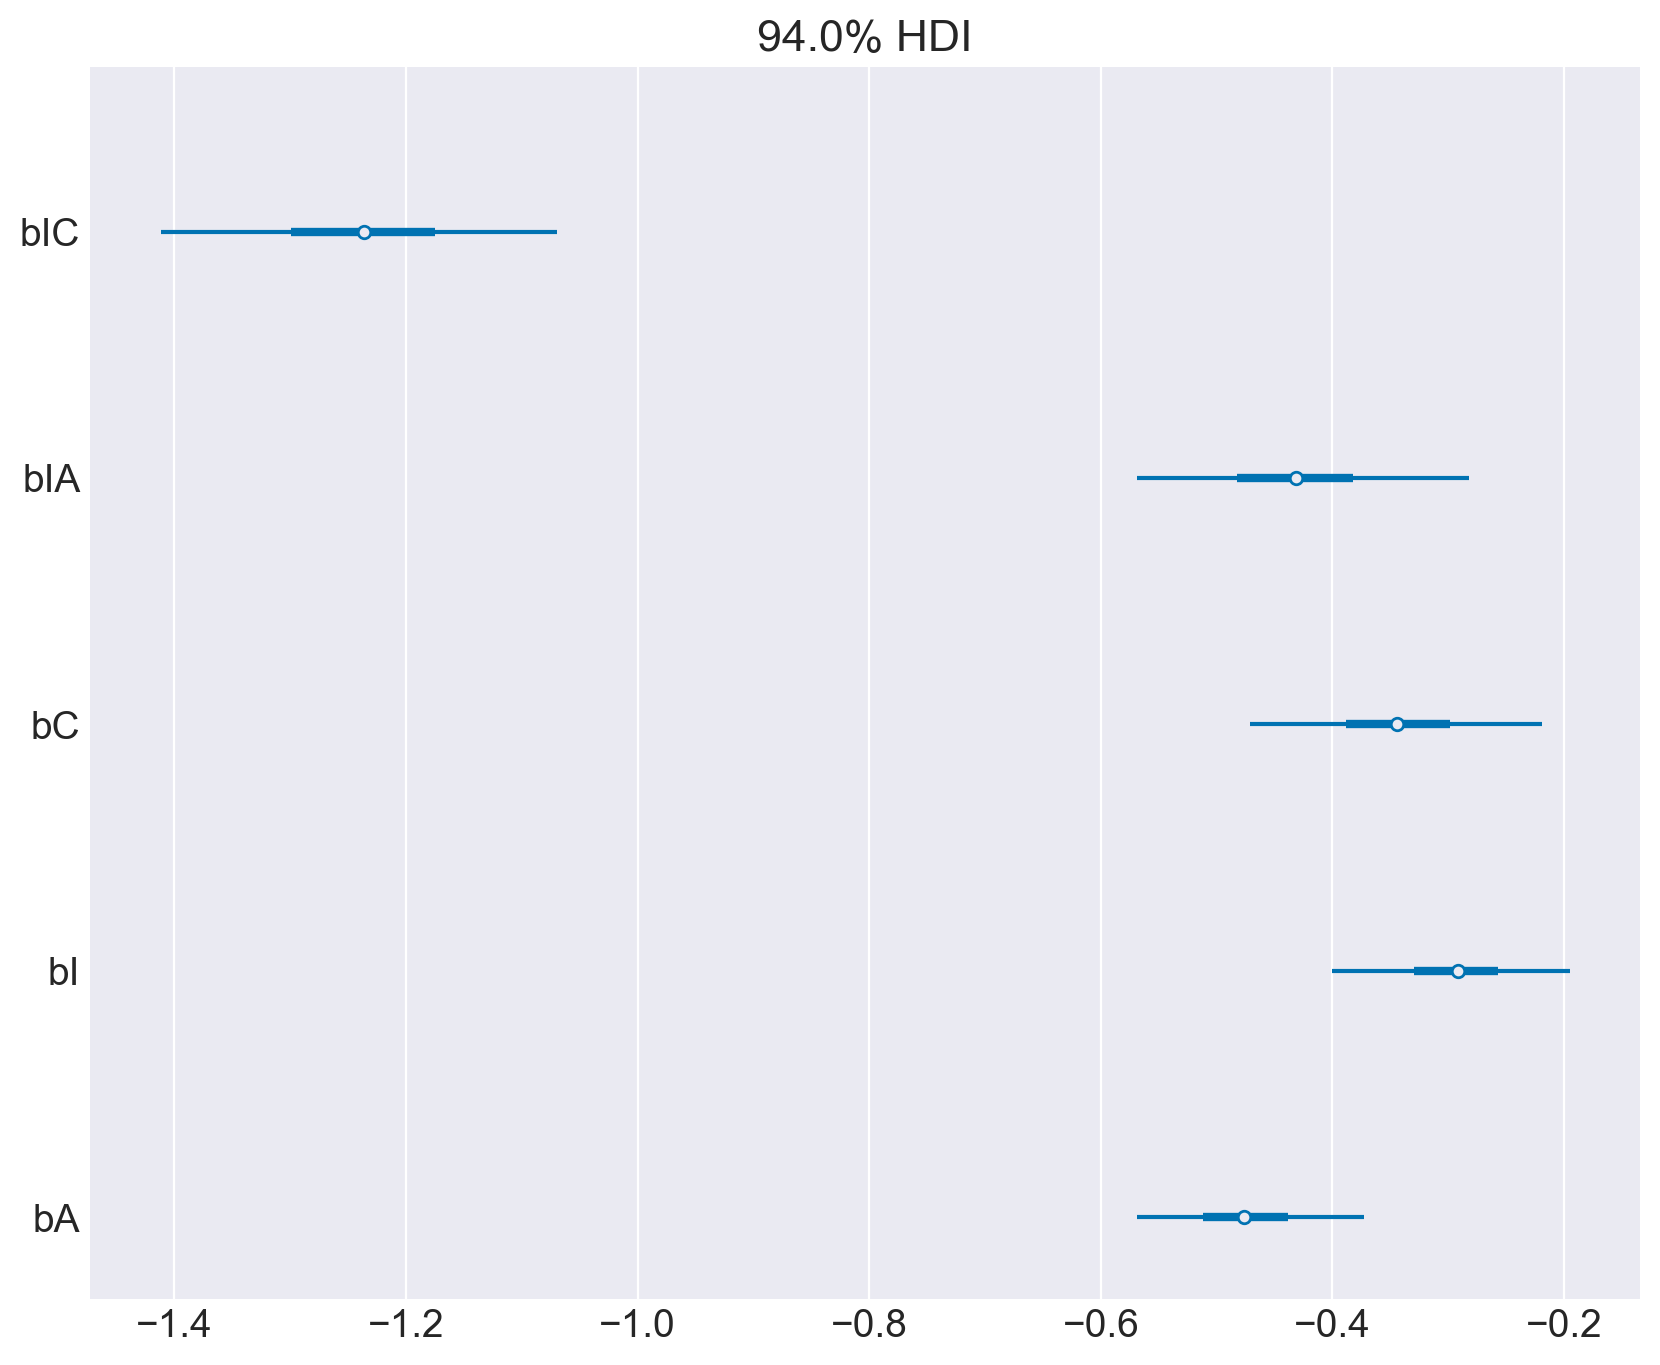

In [35]:
az.plot_forest(trace_m12_5, var_names = ['bIC', 'bIA', 'bC','bI','bA'], combined = True, figsize = (10, 8));

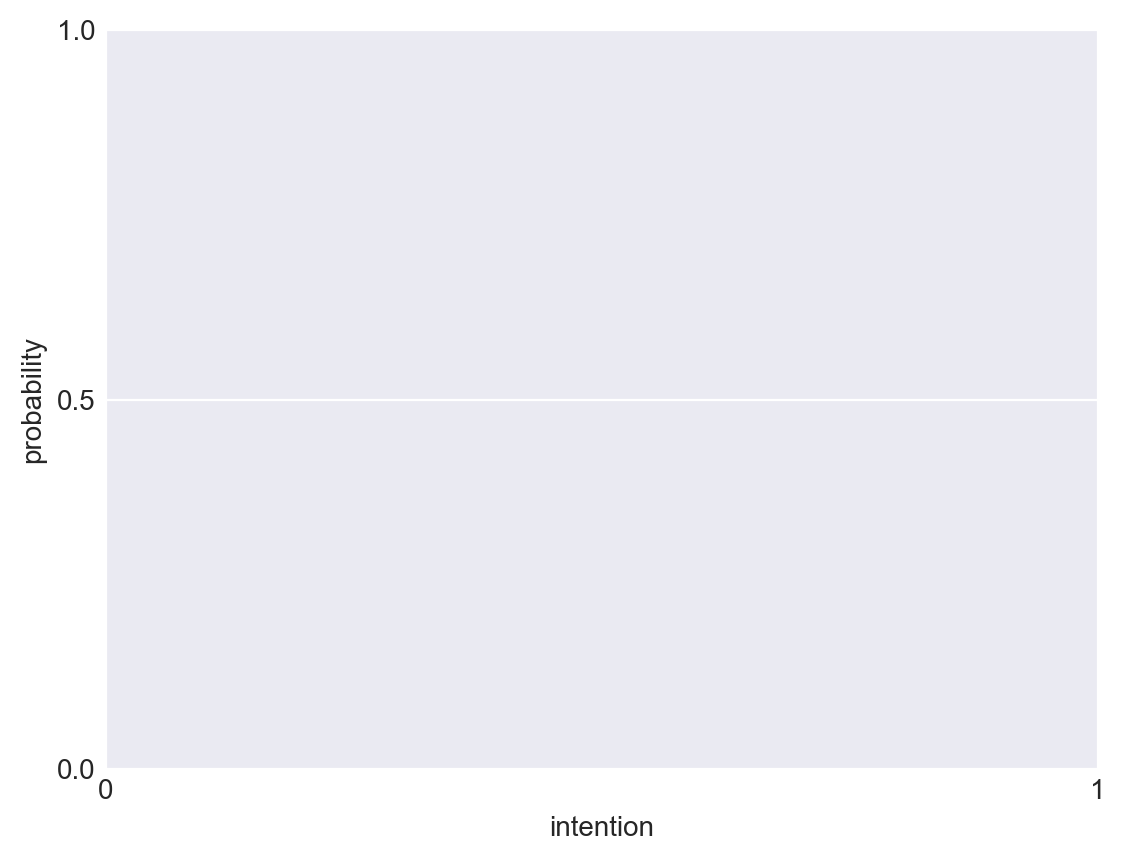

In [33]:
plt.figure()
plt.xlabel('intention')
plt.ylabel('probability')
plt.xlim(0,1)
plt.ylim(0,1)
plt.xticks([0, 1])
plt.yticks([0, 0.5, 1]);


#### Code 12.27

In [109]:
kA = 0 
kC = 0 
kI = [0,1] 
pdat = pd.DataFrame({'A': kA, 'C': kC, 'I': kI})

bA = trace_m12_5.posterior['bA'].values.flatten()
bC = trace_m12_5.posterior['bC'].values.flatten()
bI = trace_m12_5.posterior['bI'].values.flatten()

phi = (bA[:, None] * pdat['A'].values + 
       bC[:, None] * pdat['C'].values + 
       bI[:, None] * pdat['I'].values)
print(phi[:10])
(phis * kI_array.T)[:10]

[[-0.         -0.30486434]
 [-0.         -0.26284775]
 [-0.         -0.20753435]
 [-0.         -0.21563069]
 [-0.         -0.26901455]
 [-0.         -0.27148834]
 [-0.         -0.24718747]
 [-0.         -0.28948945]
 [-0.         -0.30938715]
 [-0.         -0.28616887]]


ValueError: operands could not be broadcast together with shapes (2000,) (1,2) 

#### Code 12.28

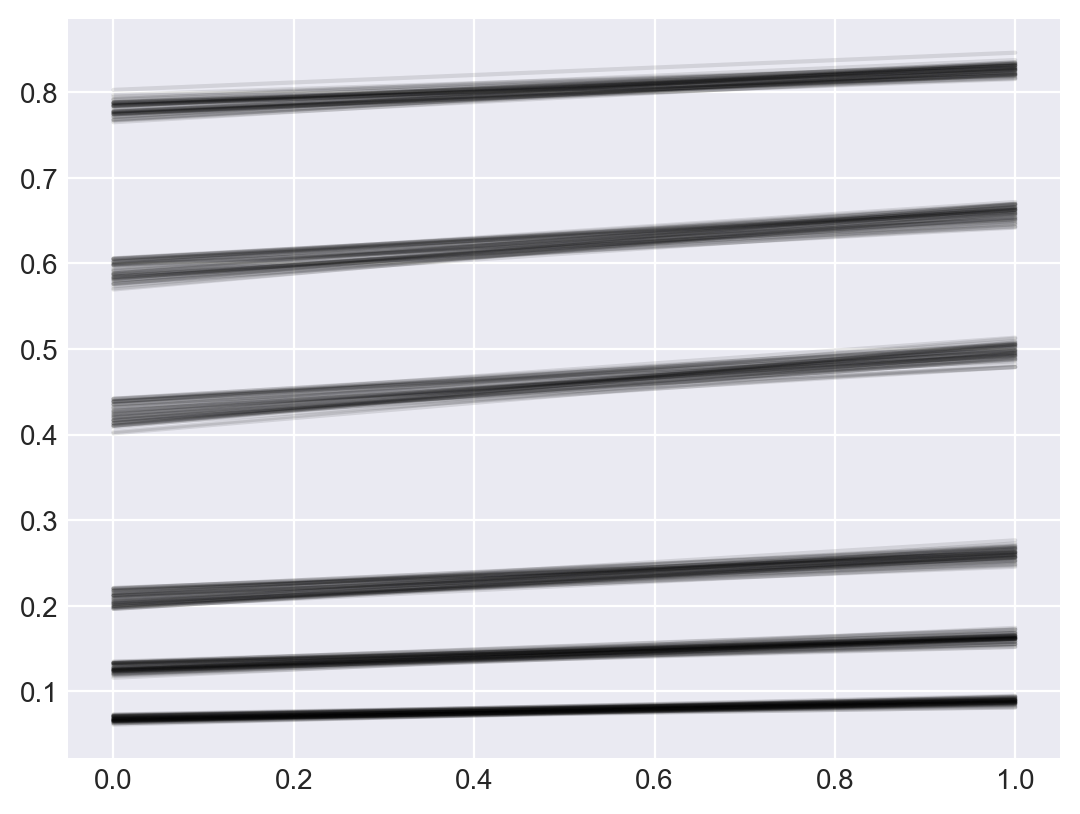

In [111]:
cutpoints = trace_m12_5.posterior['cutpoints'].values.reshape(-1, 6)  
phis = trace_m12_5.posterior['bI'].values.flatten()  
sample_idx = np.random.choice(cutpoints.shape[0], 50, replace=False)

for s in sample_idx:
    cutpoint = cutpoints[s]
    phi = phis[s]
    
    kI_array = np.array(kI)[:, None]  
    pk = inv_logit(cutpoint - (phi * kI_array))  
    for j in range(6):
        plt.plot(kI, pk[:, j], color='black', alpha=0.1)

[0.10581541 0.08554293 0.10820472 0.24485842 0.15513634 0.15208611
 0.14835606]


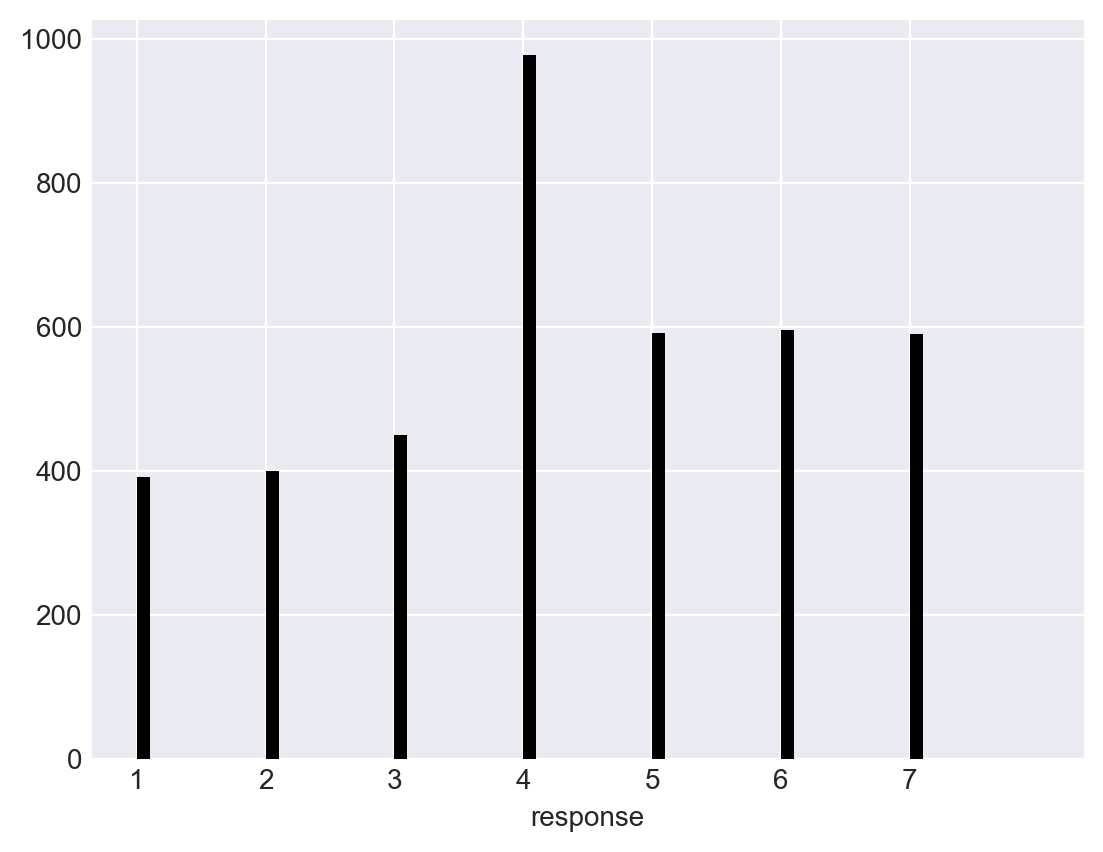

In [ ]:
kA = 0
kC = 1
kI = np.array([0, 1])

cutpoints = trace_m12_5.posterior['cutpoints'].values.reshape(-1, 6)  
bI = trace_m12_5.posterior['bI'].values.flatten()
bA = trace_m12_5.posterior['bA'].values.flatten()
bC = trace_m12_5.posterior['bC'].values.flatten()

n_samples = len(bI)

phi = bI[:, None] * kI + bA[:, None] * kA + bC[:, None] * kC  

cum_probs = inv_logit(cutpoints[:, None, :] - phi[:, :, None])

probs = np.zeros((n_samples, len(kI), 7))
probs[:, :, 0] = cum_probs[:, :, 0]
probs[:, :, 1:6] = np.diff(cum_probs, axis=2)
probs[:, :, 6] = 1 - cum_probs[:, :, 5]

probs_flat = probs.reshape(-1, 7)  
predictions = np.array([np.random.choice(7, p=p) for p in probs_flat])

plt.hist(predictions, bins=np.arange(0, 7.5, 1), 
        color = 'black', 
        width = 0.1,
        align = 'mid')
plt.xlabel('response')
plt.xticks(range(7), range(1,8))

print(probs.mean(axis=(0,1)))

#### Code 12.30

In [2]:
d = pd.read_csv('data/Trolley.csv', sep=';')
labels, unique = pd.factorize(d.edu)
raw_dict = {u:l for l,u in enumerate(unique)}

#### Code 12.31

In [3]:
edu_levels = [7,0,6,4,2,1,5,3] 
ordered_dict = {k: edu_levels.index(raw_dict.get(k)) for k in raw_dict.keys()}
d['edu_new'] = d.edu.map(ordered_dict)


#### Code 12.32

In [ ]:
np.random.seed(1806)
delta = np.random.dirichlet(np.repeat(2,7), 10)

[[0.20262736 0.1158874  0.15948582 0.17486796 0.09479264 0.19257111
  0.05976772]
 [0.06221136 0.10748562 0.11714522 0.04009098 0.4058771  0.19826302
  0.06892671]
 [0.21217626 0.04082569 0.17345963 0.27757095 0.18977284 0.05776354
  0.04843108]
 [0.08248823 0.05860489 0.1392603  0.11436409 0.10552459 0.24194721
  0.25781068]
 [0.11316253 0.13108319 0.1038401  0.09895076 0.05004054 0.2018875
  0.30103537]
 [0.1993885  0.2572198  0.07889353 0.16640919 0.07793801 0.14023003
  0.07992094]
 [0.22255498 0.13980627 0.02206734 0.23377349 0.23884218 0.05228217
  0.09067356]
 [0.11375002 0.16521162 0.11684317 0.01668502 0.19135121 0.01647926
  0.3796797 ]
 [0.17218968 0.16948808 0.07818182 0.08648324 0.26946055 0.21658012
  0.00761652]
 [0.23163785 0.11999614 0.19919897 0.07194093 0.13950506 0.13123462
  0.10648644]]


#### Code 12.33

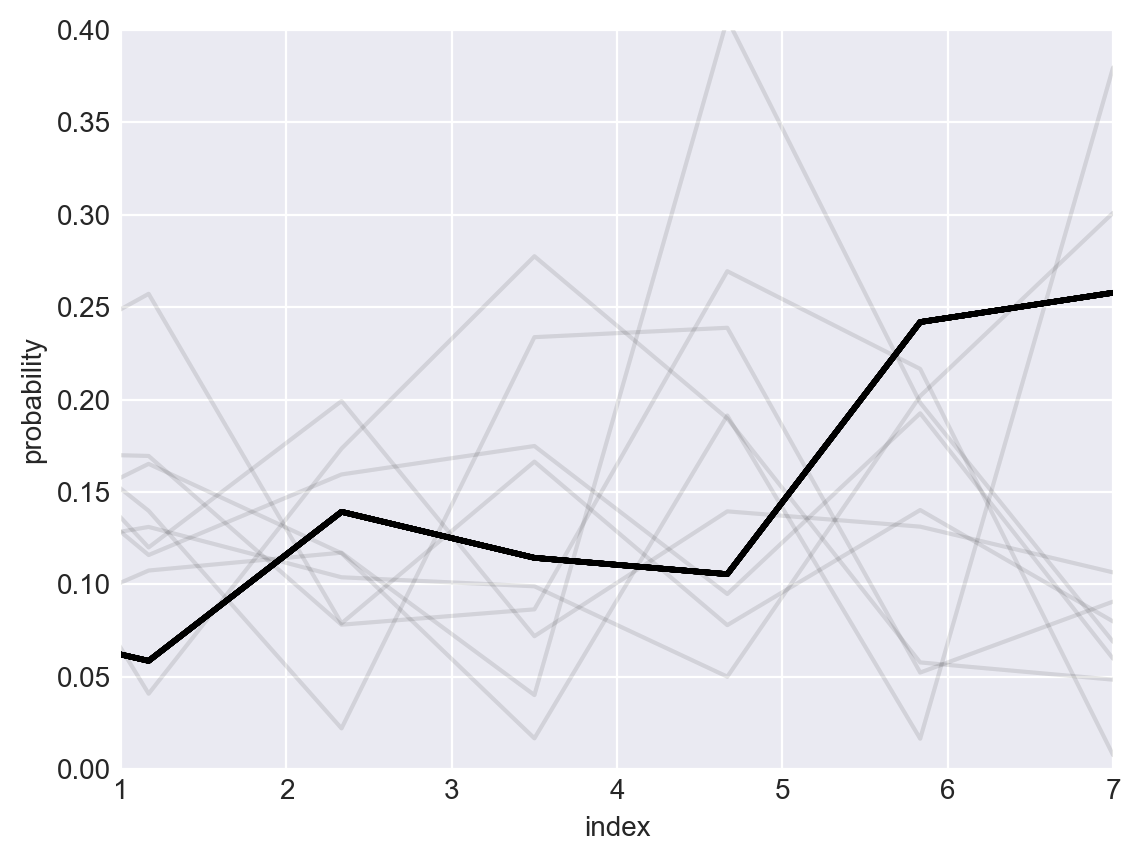

In [5]:
h = 3

plt.figure()
plt.xlim(1,7)
plt.ylim(0,.4)
plt.xlabel('index')
plt.ylabel('probability')


for i in range(delta.shape[0]):
    np.where(i!= h, plt.plot(np.linspace(0,7,7), delta[i,], color = 'black', alpha = 0.1),
    plt.plot(np.linspace(0,7,7), delta[h,], color = 'black', lw = 2))


#### Code 12.34

In [9]:
np.repeat(2,7)

array([2, 2, 2, 2, 2, 2, 2])

In [ ]:
dat = pd.DataFrame({ 
    'R': d.response,
    'action': d.action,
    'intention': d.intention,
    'contact': d.contact,
    'E': d.edu_new,
})


with pm.Model() as m12_6:
    delta = pm.Dirichlet('delta', a=np.repeat(2,7))
    delta_j = pm.Deterministic('delta_j', pm.math.concatenate([[0], delta]))
    cumsum_delta = pm.Deterministic('cumsum_delta', pm.math.cumsum(delta_j))
    
    bA = pm.Normal('bA', 0, 1)
    bI = pm.Normal('bI', 0, 1)
    bC = pm.Normal('bC', 0, 1)
    bE = pm.Normal('bE', 0, 1)
    kappa = pm.Normal('kappa', 0, 1.5, shape=6, initval=np.linspace(-2, 2, 6))
    
    phi = pm.Deterministic('phi', 
        bE * cumsum_delta[dat.E.values] +  
        bA * dat.action.values + 
        bI * dat.intention.values + 
        bC * dat.contact.values
    )
    
    R = pm.OrderedLogistic('R', eta=phi, cutpoints=kappa, 
                           observed=dat.R.values - 1)
    trace_m12_6 = pm.sample(400, tune = 400,cores=1, init="adapt_diag")






Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [delta, bA, bI, bC, bE, kappa]


Output()

Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 302 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


#### Code 12.35

In [8]:
pm.summary(trace_m12_6, var_names = ['bE', 'bC', 'bI', 'bA', 'delta'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bE,-0.258,0.160,-0.540,0.062,0.012,0.008,180.0,205.0,1.01
bC,-0.957,0.048,-1.047,-0.871,0.002,0.001,768.0,540.0,1.00
bI,-0.717,0.036,-0.781,-0.650,0.001,0.001,897.0,573.0,1.00
bA,-0.705,0.039,-0.773,-0.625,0.001,0.001,712.0,594.0,1.01
delta[0],0.218,0.133,0.015,0.447,0.007,0.006,340.0,332.0,1.00
delta[1],0.144,0.094,0.004,0.324,0.003,0.002,653.0,429.0,1.00
delta[2],0.191,0.111,0.013,0.391,0.004,0.003,712.0,481.0,1.00
delta[3],0.182,0.098,0.030,0.373,0.003,0.002,611.0,437.0,1.00
delta[4],0.053,0.064,0.001,0.146,0.004,0.003,323.0,337.0,1.01
delta[5],0.110,0.075,0.004,0.248,0.003,0.002,558.0,481.0,1.00


In [11]:
trace_m12_6

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

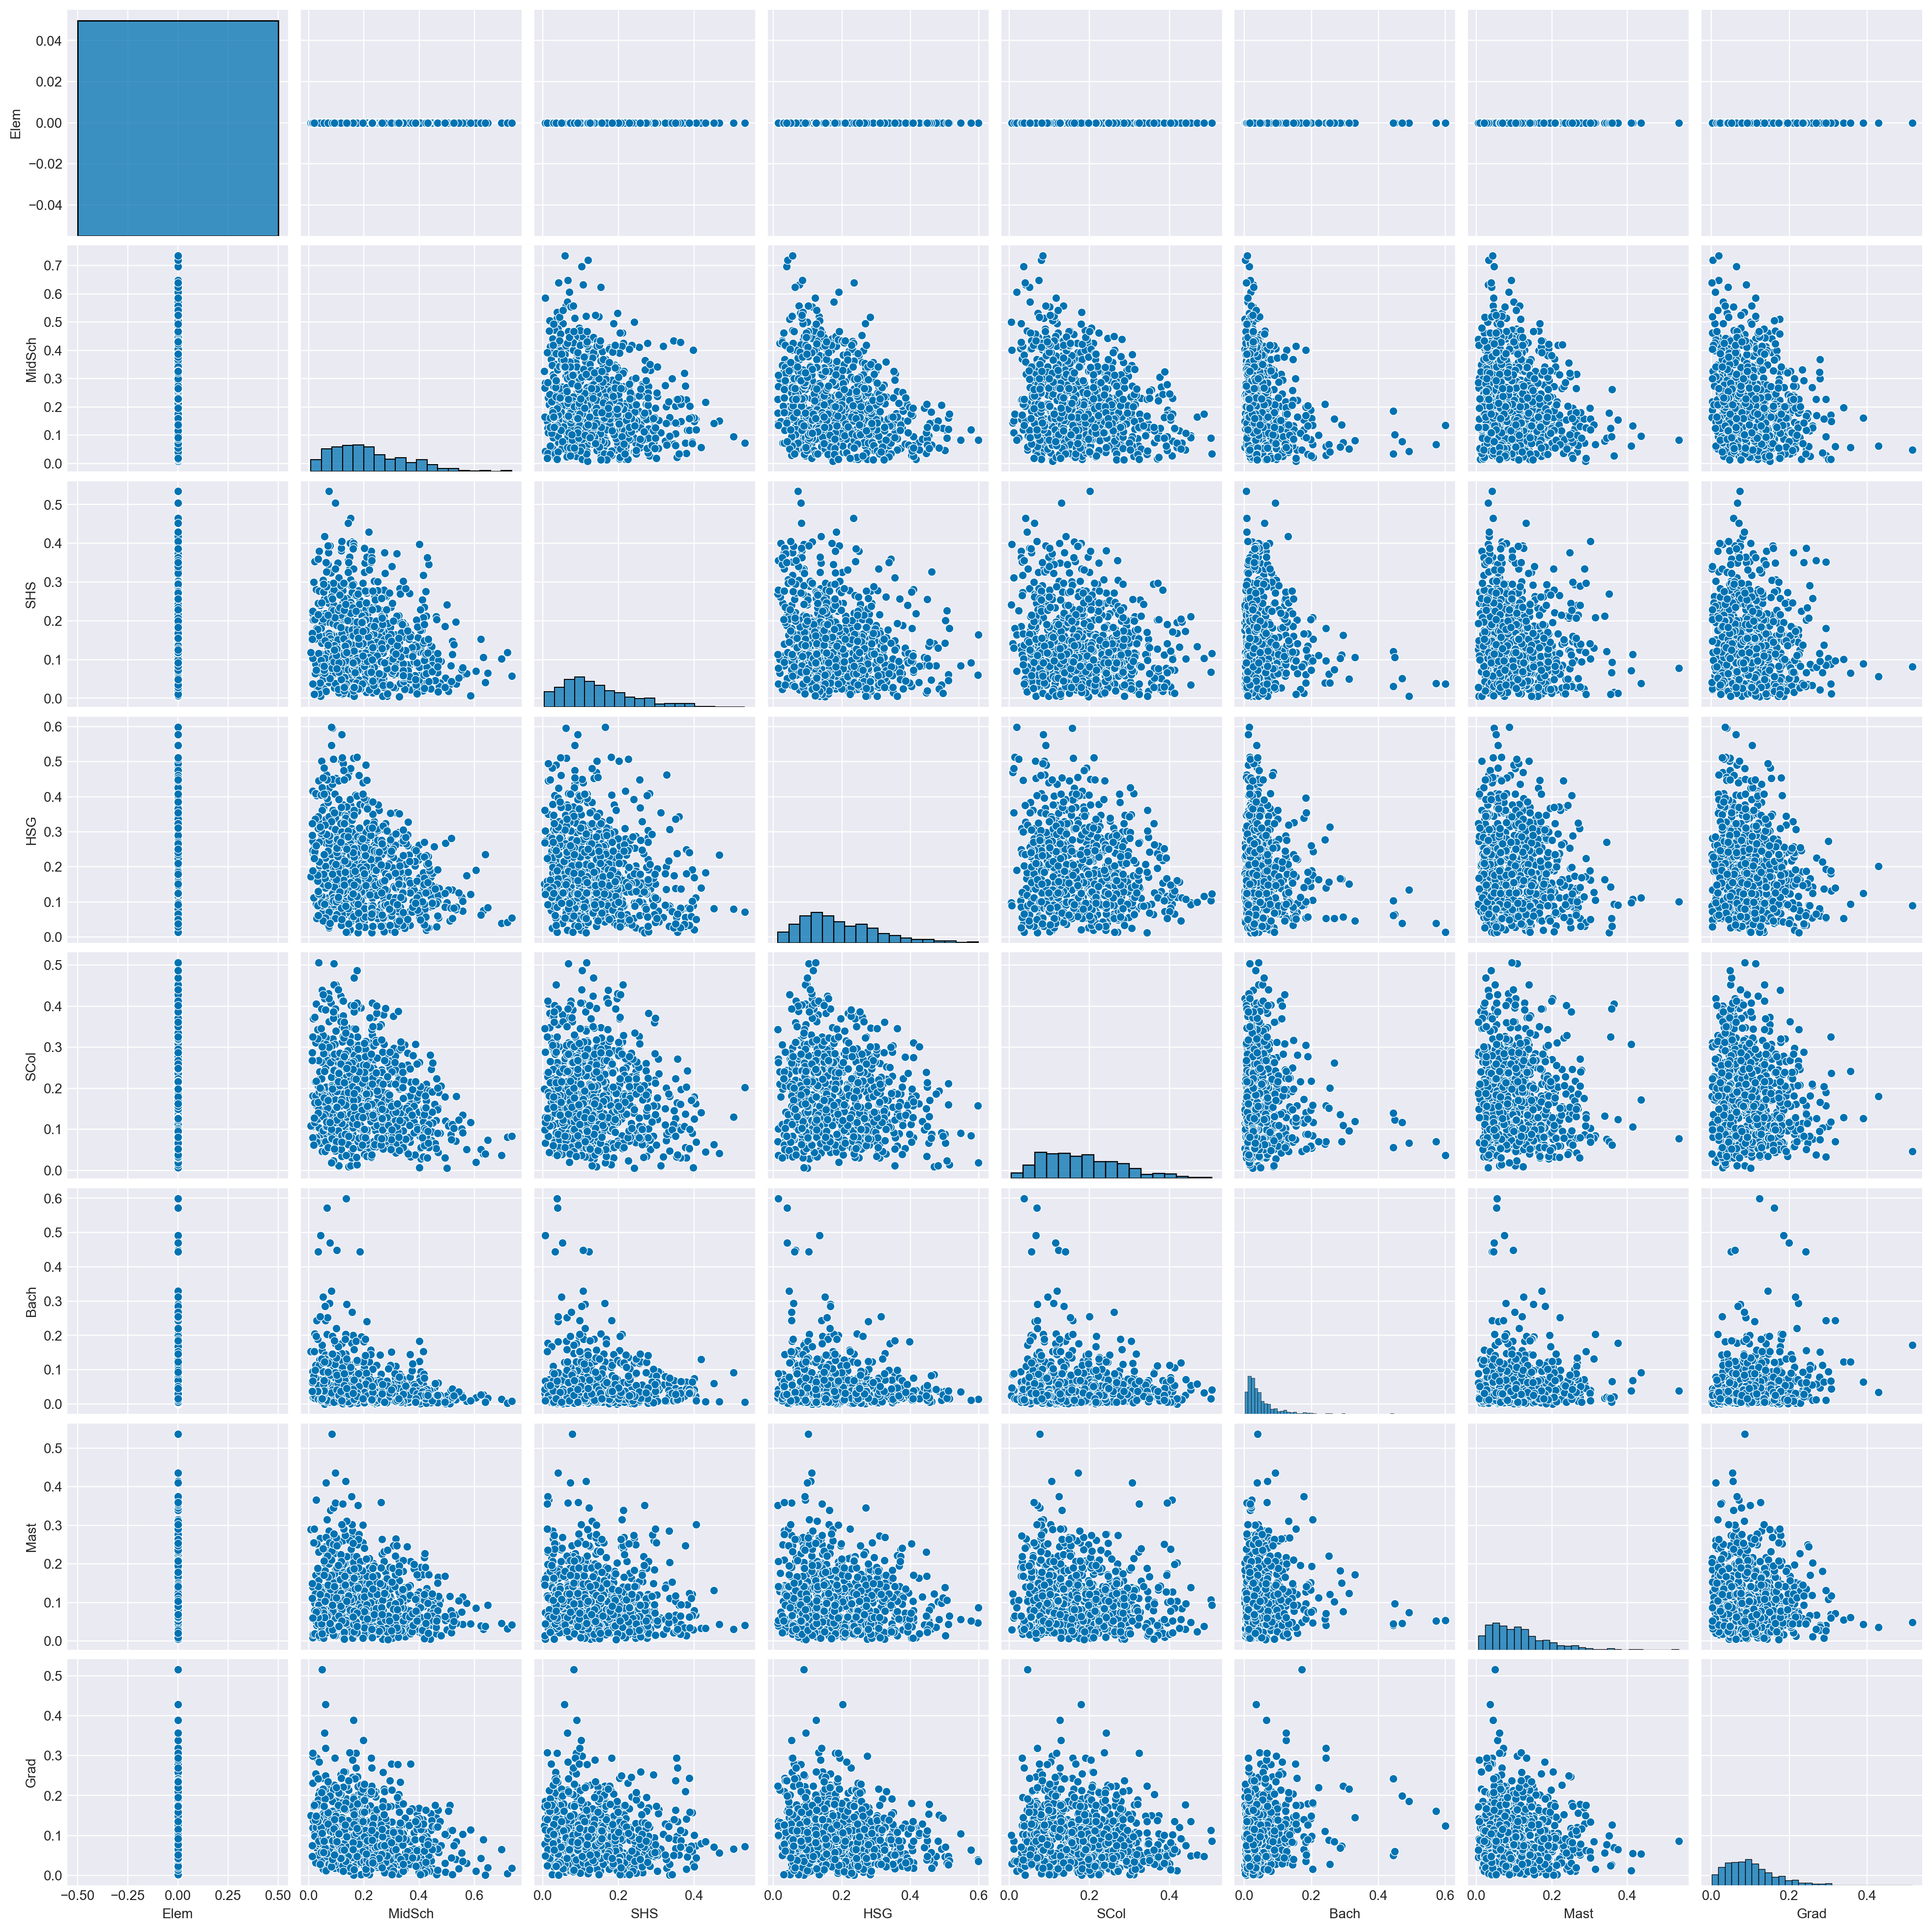

In [ ]:
delta_labels = ["Elem","MidSch","SHS","HSG","SCol","Bach","Mast","Grad"]
trace_m12_6.posterior.assign_coords(delta_j_dim_0 = delta_labels)
delta_samples = trace_m12_6.posterior['delta_j'].values.reshape(-1, 8)
delta_df = pd.DataFrame(delta_samples, columns=delta_labels)

sns.pairplot(delta_df);

#### Code 12.37

In [21]:
dat['edu_norm'] = scaler.fit_transform(d[['edu_new']])


with pm.Model() as m12_7:
    cutpoints = pm.Normal('cutpoints', 0, 1.5, shape=6,
                          initval=np.array([-1.5, -1.0, -0.5, 0, 0.5, 1.0]))
    bA = pm.Normal('bA', 0, 1)
    bI = pm.Normal('bI', 0, 1)
    bC = pm.Normal('bC', 0, 1)
    bE = pm.Normal('bE', 0, 1)
    mu = pm.Deterministic('mu', 
        bE * dat.edu_norm.values +  
        bA * dat.action.values + 
        bI * dat.intention.values + 
        bC * dat.contact.values
    )
    R = pm.OrderedLogistic('R', eta=mu, cutpoints=cutpoints, 
                           observed=dat.R.values - 1)
    trace_m12_7 = pm.sample(400, tune = 400,cores=1, init="adapt_diag")

pm.summary(trace_m12_7, var_names = ['bE', 'bC', 'bI', 'bA'])

Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [cutpoints, bA, bI, bC, bE]


Output()

Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 67 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bE,-0.016,0.018,-0.047,0.018,0.001,0.001,623.0,351.0,1.0
bC,-0.954,0.049,-1.046,-0.866,0.003,0.002,341.0,394.0,1.0
bI,-0.717,0.037,-0.785,-0.648,0.002,0.001,357.0,585.0,1.0
bA,-0.703,0.042,-0.779,-0.626,0.003,0.002,266.0,440.0,1.0
